In [23]:
import tensorflow as tf

#univariate one step problem with lstm
from numpy import array
from tensorflow.keras.models import Sequential # Import from tensorflow.keras
from tensorflow.keras.layers import Dense,  LSTM # Import from tensorflow.keras
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator # Import from tensorflow.keras

#Estas son paqueterías complementarias para la descarga de datos financieros
import pandas as pd
from pandas_datareader import data as pdr
import yfinance as yf

#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

#Plots
import matplotlib.pyplot as plt
import plotly.graph_objects as go

#Metricas
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [24]:
#Descargar datos
start = '2016-05-01'
end = '2018-01-28'
meta = yf.download("META", start, end)['Close']
meta.head()

[*********************100%***********************]  1 of 1 completed


Ticker,META
Date,
2016-05-02,117.646774
2016-05-03,116.515640
2016-05-04,117.140732
2016-05-05,116.892693
2016-05-06,118.559601


In [25]:
#pasar a data frame los datos
dt= pd.DataFrame(meta)
dt.head()

Ticker,META
Date,
2016-05-02,117.646774
2016-05-03,116.515640
2016-05-04,117.140732
2016-05-05,116.892693
2016-05-06,118.559601


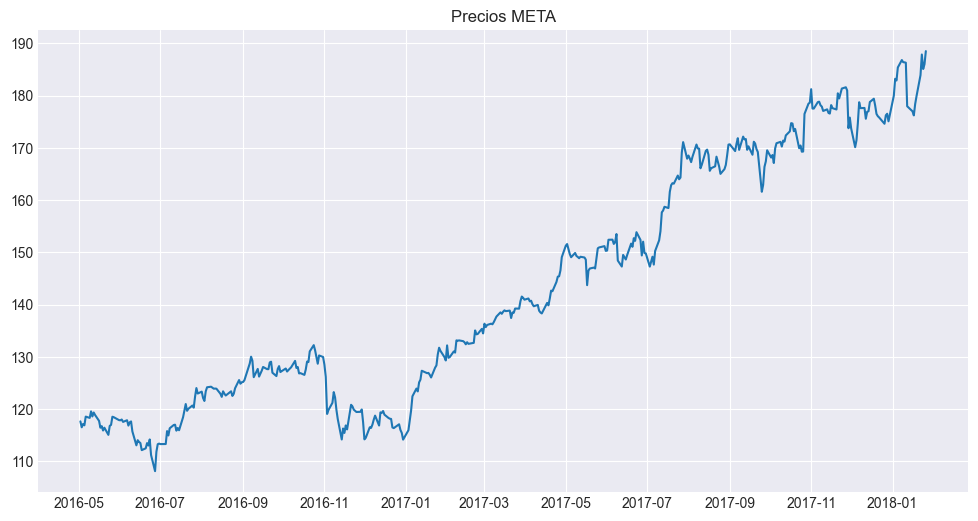

In [26]:
#Graficar los datos
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-darkgrid')
plt.title('Precios META')
plt.plot(dt)

In [27]:
#Pasar el data frame a un objeto de tiempo de pandas.
dataindex= pd.to_datetime(dt.index)
dataindex

DatetimeIndex(['2016-05-02', '2016-05-03', '2016-05-04', '2016-05-05',
               '2016-05-06', '2016-05-09', '2016-05-10', '2016-05-11',
               '2016-05-12', '2016-05-13',
               ...
               '2018-01-12', '2018-01-16', '2018-01-17', '2018-01-18',
               '2018-01-19', '2018-01-22', '2018-01-23', '2018-01-24',
               '2018-01-25', '2018-01-26'],
              dtype='datetime64[ns]', name='Date', length=439, freq=None)

In [28]:
#Pasar a numpy array:
dt2= meta.to_numpy()
dt2

array([[117.64677429],
       [116.51564026],
       [117.14073181],
       [116.89269257],
       [118.55960083],
       [118.3115387 ],
       [119.56174469],
       [118.5893631 ],
       [119.34346008],
       [118.87712097],
       [117.74599457],
       [116.43626404],
       [116.73394012],
       [115.90046692],
       [116.43626404],
       [115.0670166 ],
       [116.78353882],
       [116.97205353],
       [118.5397644 ],
       [118.45045471],
       [117.88490295],
       [117.85514069],
       [118.00395966],
       [117.54755402],
       [117.8650589 ],
       [116.84307098],
       [117.46817017],
       [117.63684082],
       [115.71194458],
       [113.06273651],
       [114.04505157],
       [113.70768738],
       [113.49931335],
       [112.13999176],
       [112.48725128],
       [113.48939514],
       [113.02305603],
       [114.18395996],
       [111.20729828],
       [108.12152863],
       [111.82247162],
       [113.27111053],
       [113.39017487],
       [113

In [29]:
close_data = dt2.reshape((-1,1))
close_data

array([[117.64677429],
       [116.51564026],
       [117.14073181],
       [116.89269257],
       [118.55960083],
       [118.3115387 ],
       [119.56174469],
       [118.5893631 ],
       [119.34346008],
       [118.87712097],
       [117.74599457],
       [116.43626404],
       [116.73394012],
       [115.90046692],
       [116.43626404],
       [115.0670166 ],
       [116.78353882],
       [116.97205353],
       [118.5397644 ],
       [118.45045471],
       [117.88490295],
       [117.85514069],
       [118.00395966],
       [117.54755402],
       [117.8650589 ],
       [116.84307098],
       [117.46817017],
       [117.63684082],
       [115.71194458],
       [113.06273651],
       [114.04505157],
       [113.70768738],
       [113.49931335],
       [112.13999176],
       [112.48725128],
       [113.48939514],
       [113.02305603],
       [114.18395996],
       [111.20729828],
       [108.12152863],
       [111.82247162],
       [113.27111053],
       [113.39017487],
       [113

In [30]:
# Partición de datos en entrenamiento 95% y prueba 5%
split_percent = 0.95
split = int(split_percent*len(close_data))

close_train = close_data[:split]
close_test = close_data[split:]

date_train = dataindex[:split]
date_test = dataindex[split:]

In [31]:
# tamaño entrenamiento y prueba 
print(len(close_train))
print(len(close_test))

417
22


In [32]:
# Transformar estructura de datos con TimeseriesGenerator
n_back = 10
train_generator = TimeseriesGenerator(close_train, close_train, length=n_back, batch_size=25)
test_generator = TimeseriesGenerator(close_test, close_test, length=n_back, batch_size=1)

In [33]:
# modelo
model = Sequential()
model.add(
    LSTM(200, 
        activation='relu',
        input_shape=(n_back,1)) 
)
model.add(Dense(1))  #capa de salida de predicción
model.compile(optimizer='adam', loss='mse')

num_epochs = 30
model.fit(train_generator, epochs=num_epochs, verbose=0)

In [34]:
history = model.fit(train_generator, epochs=num_epochs, verbose=0)

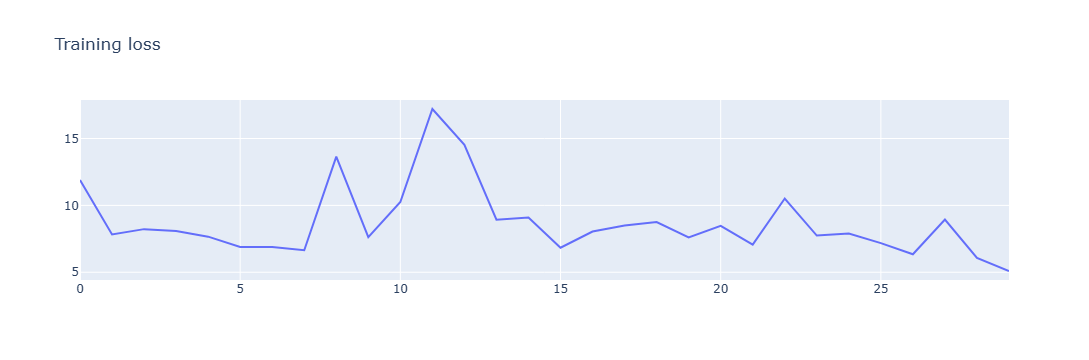

In [35]:
#gráfico de funión de pérdida acorde los epochs
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plot_data = [
    go.Scatter(
        x=hist['epoch'],
        y=hist['loss'],
        name='loss'
    )
]

plot_layout = go.Layout(
        title='Training loss')
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [36]:
#Predicción en el set de prueba:
prediction = model.predict(test_generator)

close_train = close_train.reshape((-1))
close_test = close_test.reshape((-1))
prediction = prediction.reshape((-1))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [37]:
test = close_test[n_back:]

In [38]:
#Metricas
mae = mean_absolute_error(test, prediction)
rmse = np.sqrt(mean_squared_error(test, prediction))
mape = mean_absolute_percentage_error(test, prediction)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2%}")

MAE:  3.1929
RMSE: 4.1674
MAPE: 1.77%


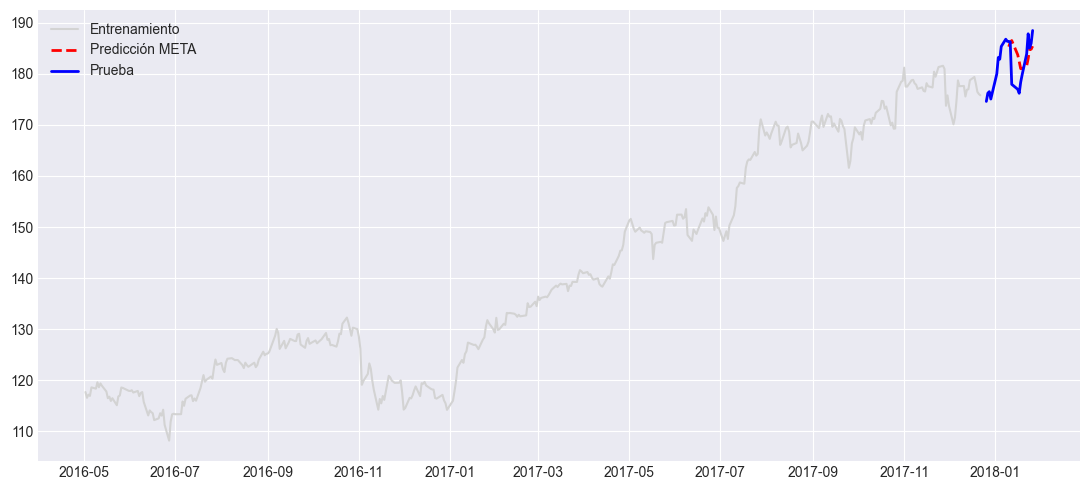

In [39]:
plt.figure(figsize=(11, 5))
plt.plot(date_train, close_train, label='Entrenamiento',  color='lightgray')
plt.plot(date_test[n_back:], prediction, label='Predicción META', linestyle='--', color='red', linewidth=2)
plt.plot(date_test, close_test, label='Prueba', color='blue', linewidth=2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Pronóstico hacia adelante (10 días)

In [40]:
close_data = dt2.reshape(-1)

In [41]:
def predict(num_prediction, model):
    prediction_list = close_data[-n_back:]

    for _ in range(num_prediction):
        x = prediction_list[-n_back:]
        x = x.reshape((1, n_back, 1)).astype(np.float32)
        out = model.predict(x, verbose=0)[0][0]
        prediction_list = np.append(prediction_list, out)

    return prediction_list[n_back-1:]  # solo forecast (sin la parte usada como entrada)

num_prediction = 10
forecast = predict(num_prediction, model)

#Fechas para el forecast:
last_date = dataindex[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=num_prediction)

In [42]:
forecast

array([188.52056885, 186.58113098, 186.85455322, 187.4907074 ,
       187.85267639, 188.22486877, 188.77763367, 189.23706055,
       189.53695679, 189.92666626, 190.32940674])

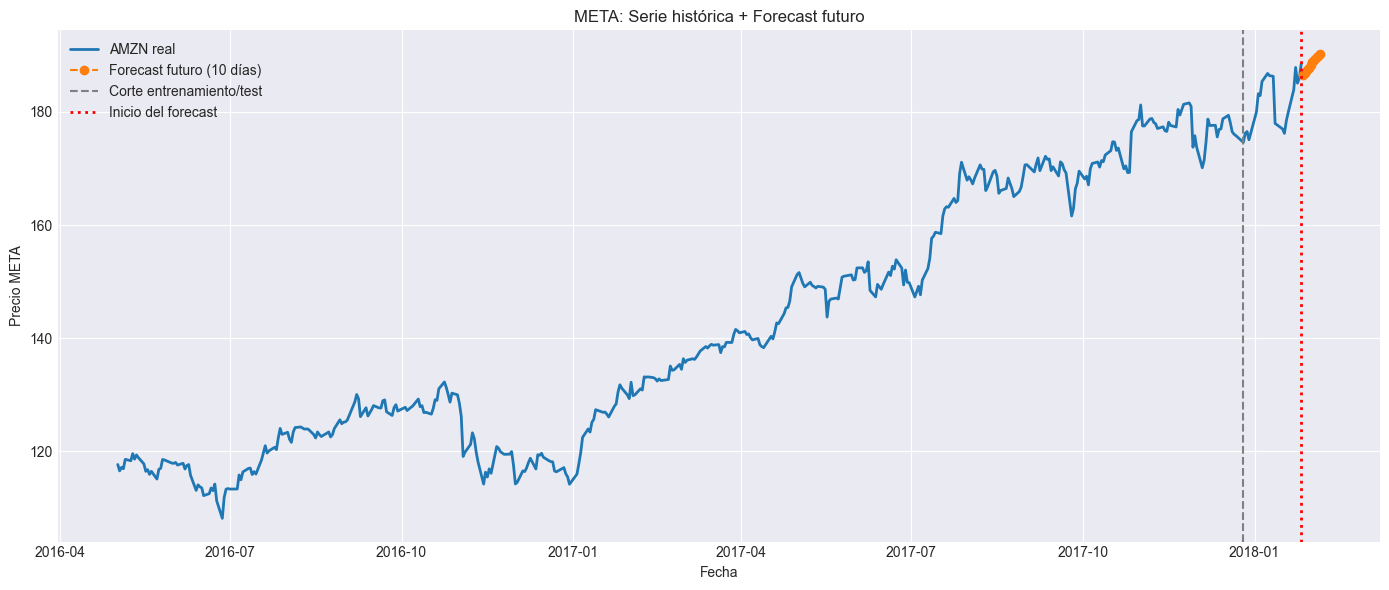

In [43]:
forecast = forecast[-10:]

# Gráfico
plt.figure(figsize=(14, 6))

plt.plot(dataindex, close_data, label='AMZN real', linewidth=2)
plt.plot(forecast_dates, forecast, label='Forecast futuro (10 días)', linestyle='--', marker='o')
plt.axvline(x=dataindex[split], color='gray', linestyle='--', linewidth=1.5, label='Corte entrenamiento/test')
plt.axvline(x=dataindex[-1], color='red', linestyle=':', linewidth=2, label='Inicio del forecast')

plt.title('META: Serie histórica + Forecast futuro')
plt.xlabel('Fecha')
plt.ylabel('Precio META')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

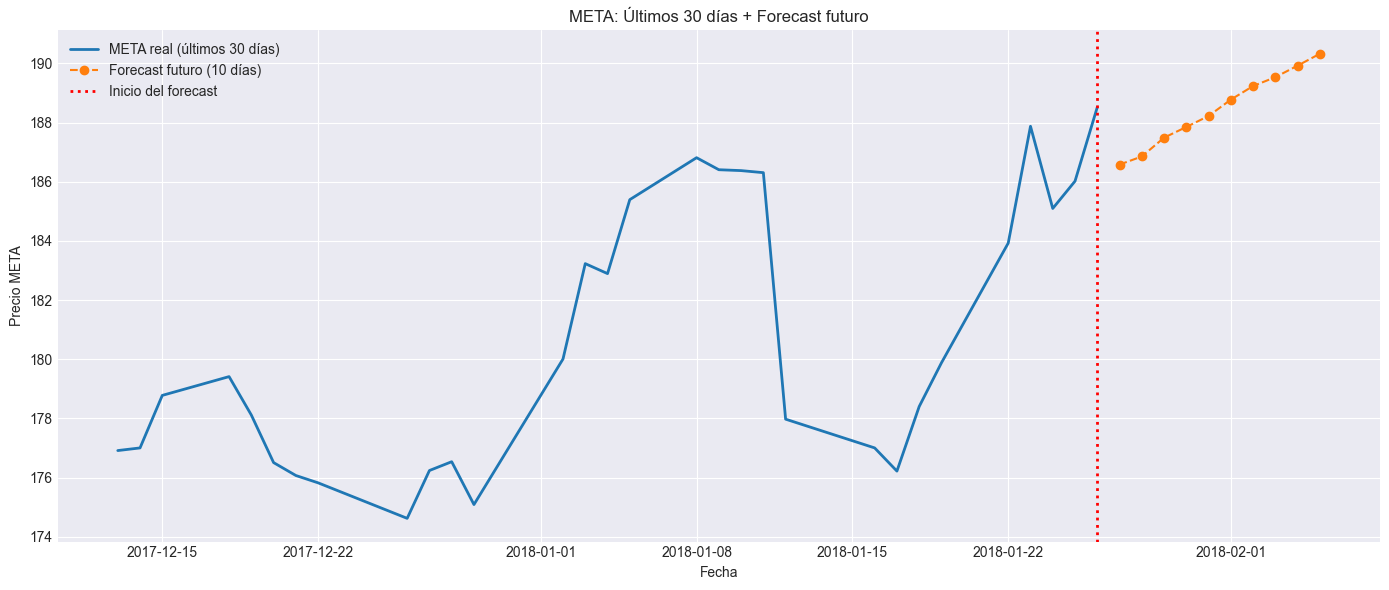

In [44]:
#ZOOM 
n_recent = 30
recent_dates = dataindex[-n_recent:]
recent_values = close_data[-n_recent:]

forecast = forecast[-10:]  
forecast_dates = forecast_dates[:10]  

# Gráfico
plt.figure(figsize=(14, 6))
plt.plot(recent_dates, recent_values, label='META real (últimos 30 días)', linewidth=2)
plt.plot(forecast_dates, forecast, label='Forecast futuro (10 días)', linestyle='--', marker='o')
plt.axvline(x=dataindex[-1], color='red', linestyle=':', linewidth=2, label='Inicio del forecast')

plt.title('META: Últimos 30 días + Forecast futuro')
plt.xlabel('Fecha')
plt.ylabel('Precio META')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()